In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import numpy as np 

In [4]:
import seaborn as sns

In [6]:
df = pd.read_csv("dataset_sucio_practica.csv")

In [7]:
df

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí
...,...,...,...,...,...,...,...,...
120,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
121,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
122,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
123,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No


In [9]:
df.shape

(125, 8)

In [10]:
df.head()

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí


In [17]:
df.describe()

,id,edad,salario
count,125.000000,110.000000,107.000000
mean,58.200000,43.945455,14093.457944
std,35.906465,47.489803,8825.918852
min,1.000000,-5.000000,-1000.000000
25%,27.000000,22.750000,12000.000000
50%,58.000000,30.000000,15000.000000
75%,89.000000,40.000000,18000.000000
max,120.000000,150.000000,25000.000000


In [18]:
df[df["id"].isin([29,55,58])]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
28,29,Teresa Ramos,22.0,rileyraymond@hotmail.com,México,-1000.0,2025-08-29,NaN
54,55,John Lewis,NaN,rodriguezbrett@yahoo.com,México,-1000.0,2024-07-03,NaN
57,58,Michael Barajas,40.0,antoniocox@hotmail.com,España,15000.0,2026-05-02,NaN


In [20]:
dfCopy = df.copy()

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              125 non-null    int64  
 1   nombre          116 non-null    str    
 2   edad            110 non-null    float64
 3   correo          125 non-null    str    
 4   pais            82 non-null     str    
 5   salario         107 non-null    float64
 6   fecha_registro  125 non-null    str    
 7   activo          90 non-null     str    
dtypes: float64(2), int64(1), str(5)
memory usage: 7.9 KB


<function matplotlib.pyplot.show(close=None, block=None)>

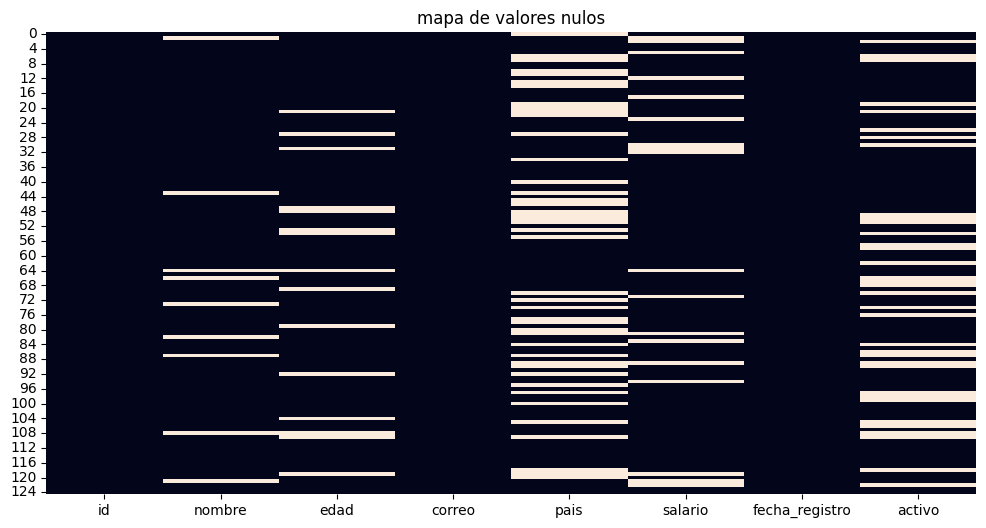

In [30]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),cbar=False)
plt.title("mapa de valores nulos")
plt.show

In [39]:
#limpieza de datos
df.duplicated().sum

<bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
115    False
116    False
117    False
118    False
119    False
Length: 120, dtype: bool>

In [38]:
df.drop_duplicates(inplace=True)

In [45]:
df[(df["edad"] < 0) | (df["edad"] > 110)]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
12,13,Paul Liu,150.0,ilong@gmail.com,España,NaN,2025-11-21,No
22,23,Mrs. Diane Carter,150.0,schultzpatrick@mccoy.net,NaN,18000.0,2024-10-31,No
40,41,Cynthia Arnold,150.0,correo_invalido,NaN,25000.0,2024-11-03,No
41,42,Patricia Morrison,150.0,uweiss@yahoo.com,Argentina,-1000.0,2026-03-10,No
61,62,John Anderson,150.0,mario37@hotmail.com,México,18000.0,2025-05-05,No
67,68,Timothy Li,150.0,molsen@gmail.com,México,12000.0,2024-10-26,NaN
74,75,Adrienne Clark,150.0,michaelwilkerson@martin.com,NaN,15000.0,2024-11-30,NaN
82,83,NaN,150.0,kristinajones@hotmail.com,México,15000.0,2024-09-01,Sí
84,85,Joel West,150.0,odonnellvicki@yahoo.com,NaN,-1000.0,2024-11-12,NaN


In [44]:
df.loc[(df["edad"])<0 | (df["edad"]>110),"edad"]= np.nan

In [46]:
#calcular mediana
mediana_edad= df["edad"].median()

In [47]:
mediana_edad

np.float64(35.0)

In [48]:
df["edad"] = df["edad"].fillna (mediana_edad)

In [49]:
df["edad"].describe()

count    120.00000
mean      47.57500
std       40.66437
min       22.00000
25%       30.00000
50%       35.00000
75%       35.00000
max      150.00000
Name: edad, dtype: float64

In [52]:
#corregir anomalia de salarios negativos
df[df["salario"]<0]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [51]:
df.loc[(df["salario"]<0),"salario"]= np.nan

In [55]:
mediana_salario=df["salario"].median()

In [56]:
mediana_salario

np.float64(15000.0)

In [57]:
df["salario"]=df["salario"].fillna(mediana_salario)

In [58]:
df["salario"].describe()

count      120.000000
mean     16741.666667
std       4401.099621
min      12000.000000
25%      15000.000000
50%      15000.000000
75%      18000.000000
max      25000.000000
Name: salario, dtype: float64

In [61]:
#corregir correos no validos
df[~df["correo"].str.contains("@",na=False)]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
3,4,Joyce Williams,30.0,NaN,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,35.0,NaN,México,25000.0,2025-03-28,Sí
18,19,Nicholas Curry,35.0,NaN,México,12000.0,2025-11-22,Sí
21,22,Carrie Griffith,35.0,NaN,NaN,15000.0,2025-05-05,NaN
30,31,Mrs. Sara Johnson,35.0,NaN,Argentina,15000.0,2026-03-07,NaN
40,41,Cynthia Arnold,150.0,NaN,NaN,25000.0,2024-11-03,No
65,66,Michael Lopez,40.0,NaN,España,15000.0,2025-12-01,No
78,79,Charles Page,25.0,NaN,NaN,15000.0,2025-09-01,No
87,88,NaN,22.0,NaN,NaN,12000.0,2025-03-07,NaN
88,89,Erika Bernard,150.0,NaN,Argentina,12000.0,2024-11-16,Sí


In [60]:
#correos no validos
correo_invalido=~df["correo"].str.contains("@",na=False)
df.loc[correo_invalido,"correo"]=pd.NA

In [67]:
#corregir paises no asignados
df["pais"].isnull().sum()

np.int64(0)

In [64]:
moda_pais=df["pais"].mode()[0]

In [65]:
moda_pais

'Argentina'

In [66]:
df["pais"]=df["pais"].fillna(moda_pais)

In [72]:
df.dtypes

id                         int64
nombre                       str
edad                     float64
correo                       str
pais                         str
salario                  float64
fecha_registro    datetime64[us]
activo                       str
dtype: object

In [71]:
#convertimos fecha 
df["fecha_registro"] = pd.to_datetime(df["fecha_registro"])

In [73]:
df["fecha_registro"].dt.year

0      2026
1      2026
2      2026
3      2025
4      2025
       ... 
115    2024
116    2024
117    2026
118    2025
119    2026
Name: fecha_registro, Length: 120, dtype: int32

In [89]:
#categorizar el campo activo
df["activo"].value_counts(dropna=False)

activo
NaN    120
Name: count, dtype: int64

In [79]:
df["activo"] = df["activo"].fillna("Sí")

In [90]:
#convertir a binario
df["activo"]= df["activo"].map({
    "Sí":1,
    "No":0
})

In [91]:
df["activo"].value_counts(dropna=False)

activo
NaN    120
Name: count, dtype: int64

In [92]:
(df.isnull().sum()/len(df))*100

id                  0.000000
nombre              6.666667
edad                0.000000
correo             10.000000
pais                0.000000
salario             0.000000
fecha_registro      0.000000
activo            100.000000
dtype: float64

# conclusiones
Durante la practica se identificaron y corrigieron los siguientes problemas
1. Borrar datos duplicados 
2. Corregir datos invalidos y atipicos
3. Realizar y corregir tipos de datos
4. Categorizar campos qus sean necesarios 